<a href="https://colab.research.google.com/github/Sezikeye/Assignment-AI/blob/main/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Flatten and combine
X = np.concatenate((
    x_train.reshape(x_train.shape[0], -1),
    x_test.reshape(x_test.shape[0], -1)
)).astype(np.float64) # Changed to float64 to ensure dtype consistency

# Normalize to [0, 1]
X /= 255.0

# Combine labels (match OpenML format: strings)
y = np.concatenate((y_train, y_test)).astype(str)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Pixel range:", X.min(), "to", X.max())

X shape: (70000, 784)
y shape: (70000,)
Pixel range: 0.0 to 1.0


In [9]:
from sklearn.cluster import KMeans

# Number of clusters (we expect ~10 digits)
k = 10

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit the model
kmeans.fit(X)

# Cluster assignments
clusters = kmeans.labels_

print("Cluster labels shape:", clusters.shape)

Cluster labels shape: (70000,)


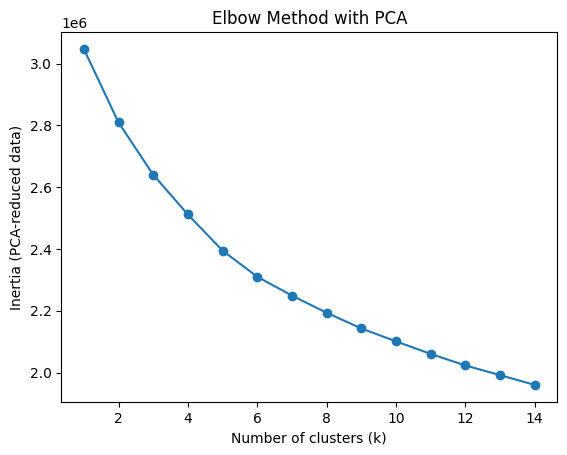

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
X_pca = pca.fit_transform(X)

inertias = []
k_values = range(1, 15)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

plt.plot(k_values, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (PCA-reduced data)")
plt.title("Elbow Method with PCA")
plt.show()

In [14]:
centroids = kmeans.cluster_centers_


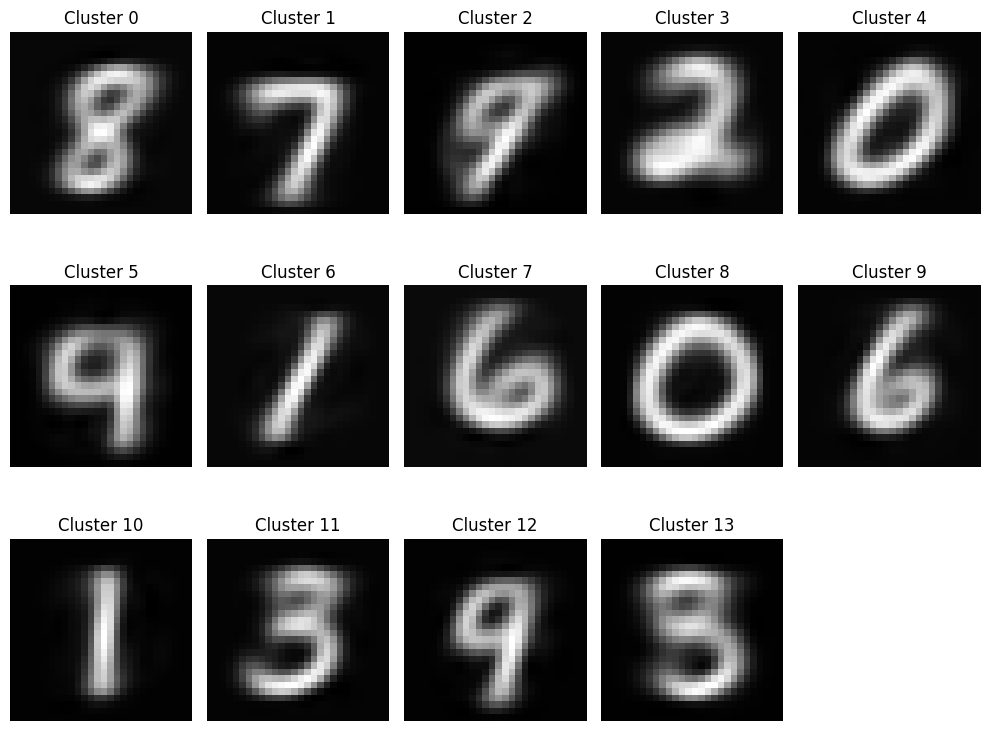

In [17]:

k = centroids.shape[0]

plt.figure(figsize=(10, 8)) # Adjusted figure size for more rows
for i in range(k):
    # Inverse transform the centroid to original 784-dimensional space before reshaping
    original_space_centroid = pca.inverse_transform(centroids[i])
    plt.subplot(3, 5, i + 1) # Changed to 3 rows to accommodate more centroids
    plt.imshow(original_space_centroid.reshape(28, 28), cmap='gray')
    plt.title(f"Cluster {i}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
from collections import Counter

cluster_labels = {}

for i in range(k):
    labels_in_cluster = y[clusters == i]
    if labels_in_cluster.size > 0: # Check if the cluster is not empty
        most_common = Counter(labels_in_cluster).most_common(1)[0][0]
    else:
        most_common = None # Assign None or another placeholder if the cluster is empty
    cluster_labels[i] = most_common

print(cluster_labels)

{0: np.str_('3'), 1: np.str_('1'), 2: np.str_('7'), 3: np.str_('6'), 4: np.str_('6'), 5: np.str_('8'), 6: np.str_('2'), 7: np.str_('1'), 8: np.str_('4'), 9: np.str_('0'), 10: None, 11: None, 12: None, 13: None}


In [21]:
predicted_digits = [cluster_labels[c] for c in clusters]
print("Predicted digits:", predicted_digits)

Predicted digits: [np.str_('8'), np.str_('0'), np.str_('4'), np.str_('1'), np.str_('7'), np.str_('2'), np.str_('1'), np.str_('8'), np.str_('1'), np.str_('7'), np.str_('3'), np.str_('1'), np.str_('3'), np.str_('6'), np.str_('1'), np.str_('7'), np.str_('2'), np.str_('8'), np.str_('6'), np.str_('7'), np.str_('4'), np.str_('0'), np.str_('7'), np.str_('1'), np.str_('6'), np.str_('2'), np.str_('4'), np.str_('3'), np.str_('7'), np.str_('1'), np.str_('1'), np.str_('8'), np.str_('6'), np.str_('7'), np.str_('6'), np.str_('6'), np.str_('6'), np.str_('6'), np.str_('4'), np.str_('6'), np.str_('1'), np.str_('8'), np.str_('1'), np.str_('7'), np.str_('1'), np.str_('7'), np.str_('8'), np.str_('6'), np.str_('3'), np.str_('8'), np.str_('3'), np.str_('0'), np.str_('4'), np.str_('1'), np.str_('7'), np.str_('8'), np.str_('0'), np.str_('7'), np.str_('4'), np.str_('1'), np.str_('4'), np.str_('1'), np.str_('6'), np.str_('0'), np.str_('6'), np.str_('1'), np.str_('6'), np.str_('1'), np.str_('3'), np.str_('3'), n

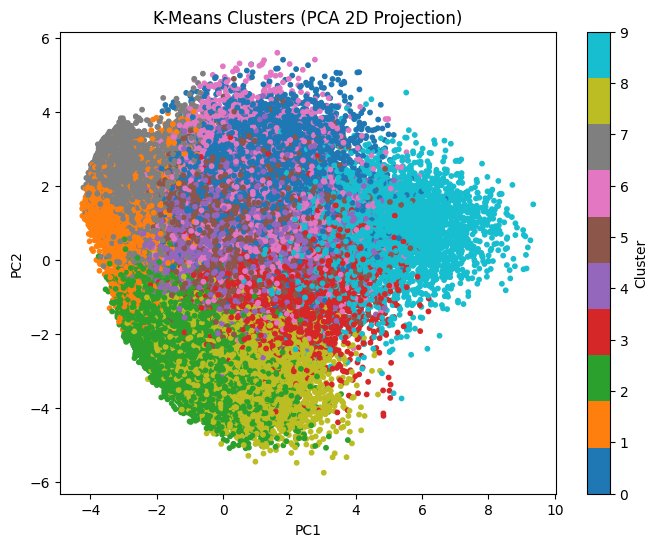

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X)

# Plot clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters, cmap='tab10', s=10)
plt.colorbar(label="Cluster")
plt.title("K-Means Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()